# $n$-per-bin threshold: Gaussian vs. binomial posterior agreement

`nick_analysis.ipynb` fits $p(\theta) = a + b \cos(2\theta)$ to binned
quenched fractions using the Navarro et al. (2021) three-parameter
Gaussian log-likelihood
$\ln p = -\tfrac{1}{2}\sum_i [(f_{q,i}-p_i)^2/s_i^2 + \ln(2\pi s_i^2)]$
with $s_i^2 = \sigma_i^2 + f^2$, sampled in $\ln f$, and $\sigma_i$
estimated by bootstrap. The standard rule of thumb ($n p \geq 5$ and
$n(1-p) \geq 5$) says the smallest actual bin ($n = 11$) is borderline,
but that rule is generic and not tuned to the fitted $(a,b)$ of *this*
dataset. This notebook produces a data-specific answer:

> At the real fitted $(a, b)$ and the real bin centers, what is the
> smallest per-bin count $n$ at which the Gaussian and binomial posteriors
> on $(a, b)$ agree to within a specified threshold?

We run a Monte Carlo sweep: at a grid of trial $n$ values, we simulate
many independent binomial datasets from the fitted $(a, b)$, refit both
the Gaussian and binomial likelihoods, and measure the posterior shift.

**Nothing in `nick_analysis.ipynb` is modified.** Section A duplicates
the setup from `nick_analysis.ipynb` so this notebook is self-contained.

---
## Section A. Setup duplicated from `nick_analysis.ipynb`

> Cells here are copied verbatim (aside from stripping unrelated plotting
> and the TNG100 branch) from `nick_analysis.ipynb`. They just reproduce
> the arrays the existing fit consumes. Skip to Section B for the new
> convergence-test code.

In [3]:
# Core numerical / plotting stack
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import scipy.stats
from scipy import stats

import astropy.units as u
import astropy.constants as const
from astropy.table import Table, join
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18 as cosmo
from astroquery.simbad import Simbad

import emcee
import corner

/Users/nicolasgarcia/opt/anaconda3/envs/py311-main/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


In [4]:
# --- SAGA load + r200c cut + per-satellite projected angle (copied) ---
saga_hosts = Table.read('../saga-dr3-tableC1.txt', format='ascii')
saga_sats = Table.read('../saga-dr3-tableC3.txt', format='ascii')
saga_joined = join(saga_sats, saga_hosts, 'HOSTID', 'left',
                   uniq_col_name='{table_name}{col_name}',
                   table_names=['', 'HOST_'])

def calc_r200(mhalo):
    mhalo = mhalo * u.Msun
    delta = 200
    rho_c = cosmo.critical_density0
    r200_c = ((3 * mhalo / (4. * np.pi * delta * rho_c)) ** (1. / 3.)).to(u.kpc)
    rho_m = cosmo.critical_density0 * cosmo.Om0
    r200_m = ((3 * mhalo / (4. * np.pi * delta * rho_m)) ** (1. / 3.)).to(u.kpc)
    return r200_c.value, r200_m.value

hosts_log_mhalo_array = saga_hosts['log(Mhalo)'].data

saga_PA = np.zeros(len(saga_sats))
saga_quenched = saga_sats['quenched'].data
for m in range(len(saga_hosts)):
    h_c = SkyCoord(saga_hosts['RAdeg'][m], saga_hosts['DEdeg'][m], frame="icrs", unit="deg")
    for n_ in range(len(saga_sats)):
        if saga_hosts['HOSTID'][m] == saga_sats['HOSTID'][n_]:
            PA = saga_hosts['PA'][m]
            s_c = SkyCoord(saga_sats['RAdeg'][n_], saga_sats['DEdeg'][n_], frame="icrs", unit="deg")
            relative_angle = h_c.position_angle(s_c).degree
            saga_PA[n_] = ((90 - PA) + (90 + relative_angle)) % 360

def map_to_0_90(angles):
    angles = np.mod(angles, 360)
    return np.where(angles <= 90, angles,
           np.where(angles <= 180, 180 - angles,
           np.where(angles <= 270, angles - 180,
                    360 - angles)))

r200c_hosts = np.zeros(len(saga_sats))
sats_rhost_array = saga_sats['Rhost'].data
host_data = {saga_hosts['HOSTID'][i]: hosts_log_mhalo_array[i] for i in range(len(saga_hosts))}
for i in range(len(saga_sats)):
    host_id = saga_sats['HOSTID'][i]
    if host_id in host_data:
        r200c_i, _ = calc_r200(10 ** host_data[host_id])
        r200c_hosts[i] = r200c_i

sample = np.array(saga_sats['sample'])
index_final = (sats_rhost_array < r200c_hosts) & ((sample == 1.) | (sample == 2.))
saga_PA = saga_PA[index_final]
saga_90 = map_to_0_90(saga_PA)
saga_quenched = saga_quenched[index_final]
print("SAGA final N satellites:", len(saga_90))

SAGA final N satellites: 269


In [5]:
# --- ELVES load + SIMBAD PA + per-satellite angle (copied) ---
sats = pd.read_csv('../Carlsten22_ELVES_confirmed_sats - Carlsten22_ELVES_confirmed_sats_compre.csv')
hosts_unfiltered = pd.read_csv(
    "../Carlsten22_ELVES_host - Carlsten22_ELVES_host.csv",
    skipfooter=1, engine="python",
)
customSimbad = Simbad()
customSimbad.reset_votable_fields()
customSimbad.add_votable_fields('ra', 'dec', 'galdim_angle', 'galdim_majaxis', 'galdim_minaxis')

pa_list = []
kept_indices = []
for r in range(len(sats)):
    host = sats['Host'].get(r)
    h_table = Simbad.query_object(host)
    pa_tab = customSimbad.query_object(host)
    pa_col = pa_tab['galdim_angle']
    if np.ma.is_masked(pa_col):
        continue
    try:
        h_coords = SkyCoord(ra=h_table['ra'], dec=h_table['dec'], frame='icrs')
        s_coords = SkyCoord(ra=sats['RA(deg)'].get(r),
                            dec=sats['DEC(deg)'].get(r),
                            frame='icrs', unit='deg')
    except Exception:
        continue
    position_angle = h_coords.position_angle(s_coords).degree
    angle = ((90 - pa_col.value) + position_angle + 90) % 360
    pa_list.append(angle)
    kept_indices.append(r)

elves_PA = np.array(pa_list, dtype=float)
elves_quenched = np.array(sats['ETG?'].iloc[kept_indices])
elves_90 = map_to_0_90(elves_PA)
elves_90_correct = np.array([elves_90[i][0] for i in range(len(elves_90))])
print("ELVES final N satellites:", len(elves_90_correct))

ELVES final N satellites: 177


In [6]:
# --- Bootstrap binning (copied, verbatim function) ---
def bootstrap_90_observational_binned(x, y, N=10000, bins=18, angle_range=(0, 90)):
    x = np.asarray(x)
    y = np.asarray(y, dtype=float)
    bin_edges = np.linspace(angle_range[0], angle_range[1], bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    fq_mean = np.full(bins, np.nan)
    fq_std = np.full(bins, np.nan)
    rng = np.random.default_rng()
    for j in range(bins):
        in_bin = (x >= bin_edges[j]) & (x < bin_edges[j + 1])
        y_bin = y[in_bin]
        if len(y_bin) < 2:
            continue
        idx = rng.integers(0, len(y_bin), size=(N, len(y_bin)))
        boot_fq = y_bin[idx].mean(axis=1)
        fq_mean[j] = boot_fq.mean()
        fq_std[j] = boot_fq.std()
    return bin_centers, fq_mean, fq_std

np.random.seed(42)
bin_centers, fq_mean_saga, fq_std_saga = bootstrap_90_observational_binned(saga_90, saga_quenched, N=10000)
_, fq_mean_elves, fq_std_elves = bootstrap_90_observational_binned(elves_90_correct, elves_quenched, N=10000)

# per-bin counts and quenched counts
def per_bin_counts(theta, q, bins=18, angle_range=(0, 90)):
    edges = np.linspace(angle_range[0], angle_range[1], bins + 1)
    n_i, _ = np.histogram(theta, bins=edges)
    q_bool = np.asarray(q, dtype=float) > 0.5
    k_i, _ = np.histogram(np.asarray(theta)[q_bool], bins=edges)
    return n_i, k_i

n_saga, k_saga = per_bin_counts(saga_90, saga_quenched)
n_elves, k_elves = per_bin_counts(elves_90_correct, elves_quenched)
print("SAGA n_i per bin:", n_saga.tolist(), " min =", int(n_saga.min()))
print("ELVES n_i per bin:", n_elves.tolist(), " min =", int(n_elves.min()))

SAGA n_i per bin: [13, 14, 13, 19, 17, 10, 14, 11, 8, 18, 19, 15, 13, 16, 16, 21, 15, 17]  min = 8
ELVES n_i per bin: [9, 11, 11, 15, 7, 10, 11, 7, 7, 11, 12, 6, 9, 8, 8, 7, 19, 9]  min = 6


---
## Section B. New: fit real $(a, b)$ on the actual data

The convergence sweep injects binomial data at fixed $(a_{\rm true},
b_{\rm true})$; those "true" values are the posterior medians of the
**actual** SAGA / ELVES Gaussian fit on the current binned data (with the
3-parameter $a, b, \ln f$ likelihood that `nick_analysis.ipynb` uses).

In [7]:
# 3-param Gaussian likelihood exactly matching nick_analysis.ipynb's
# calculate_log_likelihood / log_prior / calculate_log_probability.
def loglike_gauss3(params, theta_deg, fq, sig):
    a, b, lnf = params
    s2 = sig ** 2 + np.exp(lnf) ** 2
    mu = a + b * np.cos(2 * np.radians(theta_deg))
    return -0.5 * np.sum((fq - mu) ** 2 / s2 + np.log(2 * np.pi * s2))

def logpost_gauss3(params, theta_deg, fq, sig):
    a, b, lnf = params
    if not (0 < a < 1 and -1 < b < 1 and -10 < lnf < 2):
        return -np.inf
    return loglike_gauss3(params, theta_deg, fq, sig)

def run_sampler(logpost, args, init, n_walkers=20, n_steps=5000, burnin=500, seed=0):
    rng = np.random.default_rng(seed)
    ndim = len(init)
    pos = np.array(init) + rng.normal(size=(n_walkers, ndim)) * 1e-2
    sampler = emcee.EnsembleSampler(n_walkers, ndim, logpost, args=args)
    sampler.run_mcmc(pos, n_steps, progress=False)
    return sampler.get_chain(discard=burnin, flat=True)

# Only use bins with a well-defined bootstrap sigma, same guard as nick_analysis
valid_saga = np.isfinite(fq_mean_saga) & np.isfinite(fq_std_saga) & (fq_std_saga > 0) & (n_saga > 0)
valid_elves = np.isfinite(fq_mean_elves) & np.isfinite(fq_std_elves) & (fq_std_elves > 0) & (n_elves > 0)

# Use the same nick_analysis MCMC settings for the real fit (walkers=20, steps=10000, burnin=1000)
samp_saga_real = run_sampler(logpost_gauss3,
                             (bin_centers[valid_saga], fq_mean_saga[valid_saga], fq_std_saga[valid_saga]),
                             init=[0.7, 0.025, -3.0], n_walkers=20, n_steps=10000, burnin=1000, seed=1)
samp_elves_real = run_sampler(logpost_gauss3,
                              (bin_centers[valid_elves], fq_mean_elves[valid_elves], fq_std_elves[valid_elves]),
                              init=[0.7, 0.025, -3.0], n_walkers=20, n_steps=10000, burnin=1000, seed=2)

a_saga_true, b_saga_true = np.median(samp_saga_real[:, 0]), np.median(samp_saga_real[:, 1])
a_elves_true, b_elves_true = np.median(samp_elves_real[:, 0]), np.median(samp_elves_real[:, 1])
print(f"SAGA fitted:  a = {a_saga_true:.4f}, b = {b_saga_true:.4f}")
print(f"ELVES fitted: a = {a_elves_true:.4f}, b = {b_elves_true:.4f}")

SAGA fitted:  a = 0.2503, b = -0.0334
ELVES fitted: a = 0.6330, b = 0.0386


### B.1 Also record the posterior std as a "natural" per-fit width
Used later to normalize shifts in $(a, b)$ into $\sigma$ units against the
real-data posterior width, so "0.2 $\sigma$" means 0.2 of the width of the
posterior actually reported for this analysis.

In [8]:
sigma_a_saga = float(np.std(samp_saga_real[:, 0]))
sigma_b_saga = float(np.std(samp_saga_real[:, 1]))
sigma_a_elves = float(np.std(samp_elves_real[:, 0]))
sigma_b_elves = float(np.std(samp_elves_real[:, 1]))
print(f"SAGA real-fit posterior widths:  sigma_a = {sigma_a_saga:.4f}, sigma_b = {sigma_b_saga:.4f}")
print(f"ELVES real-fit posterior widths: sigma_a = {sigma_a_elves:.4f}, sigma_b = {sigma_b_elves:.4f}")

SAGA real-fit posterior widths:  sigma_a = 0.0279, sigma_b = 0.0402
ELVES real-fit posterior widths: sigma_a = 0.0456, sigma_b = 0.0621


---
## Section C. Convergence-test likelihoods and simulator

The Gaussian likelihood used in the sweep is the **exact** three-parameter
Navarro et al. (2021) form, matching `nick_analysis.ipynb`:

$$\ln p = -\tfrac{1}{2}\sum_i \left[\frac{(f_{q,i}-a-b\cos 2\theta_i)^2}{s_i^2}
  + \ln(2\pi s_i^2)\right],\quad s_i^2 = \sigma_i^2 + f^2$$

with the sampled variable being $\ln f$ (natural log) — i.e. in code
`s_i^2 = sigma_i^2 + np.exp(lnf)**2`. Priors also match: $0<a<1$,
$-1<b<1$, $-10<\ln f<2$. Because the binomial likelihood has no jitter
parameter, we compare the two only on the $(a, b)$ marginals.

In [9]:
CLIP_LOW, CLIP_HIGH = 1e-6, 1 - 1e-6

def _valid_p(theta_deg, a, b):
    p = a + b * np.cos(2 * np.radians(theta_deg))
    return p, np.all(p > 0) and np.all(p < 1)

def logprior_ab(p):
    a, b = p
    if 0 < a < 1 and -1 < b < 1:
        return 0.0
    return -np.inf

def logprior_abf(p):
    a, b, lnf = p
    if 0 < a < 1 and -1 < b < 1 and -10 < lnf < 2:
        return 0.0
    return -np.inf

def logpost_gauss3(params, theta_deg, fq, sig):
    """Navarro et al. (2021) exact form, matching nick_analysis.ipynb."""
    lp = logprior_abf(params)
    if not np.isfinite(lp):
        return -np.inf
    a, b, lnf = params
    s2 = sig ** 2 + np.exp(lnf) ** 2
    mu = a + b * np.cos(2 * np.radians(theta_deg))
    return -0.5 * np.sum((fq - mu) ** 2 / s2 + np.log(2 * np.pi * s2))

def logpost_binom(params, theta_deg, n_i, k_i):
    lp = logprior_ab(params)
    if not np.isfinite(lp):
        return -np.inf
    a, b = params
    p, ok = _valid_p(theta_deg, a, b)
    if not ok:
        return -np.inf
    p = np.clip(p, CLIP_LOW, CLIP_HIGH)
    return np.sum(scipy.stats.binom.logpmf(k_i, n_i, p))

def _wald_sigma(k, n):
    p_hat = k / n
    var = p_hat * (1 - p_hat) / n
    # Floor to 1/(4n) so a bin with k=0 or k=n still has finite sigma;
    # this is a mild Agresti-style stabilization that lets the Gaussian
    # likelihood be defined -- if it "fails" at low n that's the point of
    # this test.
    var = np.maximum(var, 0.25 / (n * n))
    return np.sqrt(var)

### C.1 Posterior-shift metrics

For each simulated dataset we get a Gaussian posterior sample cloud and a
binomial posterior sample cloud, both on $(a, b)$. We report:

- **`shift_a_sigma`** and **`shift_b_sigma`**: $|\mu_{\rm Gauss} - \mu_{\rm
  binom}|$ divided by the combined posterior std
  $\sqrt{\sigma_{\rm Gauss}^2 + \sigma_{\rm binom}^2}$ per parameter.
  Reduces to 0 when the two posteriors coincide.
- **`shift_a_real`** and **`shift_b_real`**: same shift in numerator, but
  normalized instead by the **real-data** posterior width $\sigma_a$ /
  $\sigma_b$ from Section B, so the threshold applies to the actual
  analysis' reported error bars.
- **KL divergence** between 2D Gaussian approximations to the two
  posterior clouds, treating $p_{\rm binom}$ as the reference distribution.

In [10]:
def fit_gauss2d(samples):
    return samples.mean(axis=0), np.cov(samples, rowvar=False)

def kl_divergence_2d(mu_p, cov_p, mu_q, cov_q):
    """KL(P || Q) for 2D Gaussians."""
    k = mu_p.size
    cov_q_inv = np.linalg.inv(cov_q)
    diff = (mu_q - mu_p).reshape(-1, 1)
    sign_p, logdet_p = np.linalg.slogdet(cov_p)
    sign_q, logdet_q = np.linalg.slogdet(cov_q)
    trace_term = np.trace(cov_q_inv @ cov_p)
    mah_term = float(diff.T @ cov_q_inv @ diff)
    return 0.5 * (trace_term + mah_term - k + logdet_q - logdet_p)

### C.2 The sweep

One `run_sweep` call does everything for one dataset: at each candidate $n$,
simulate `n_repeats` binomial datasets at the fitted $(a_{\rm true},
b_{\rm true})$ and real bin centers, fit both likelihoods, and average
the metrics across repeats.

In [11]:
def run_sweep(a_true, b_true, bin_centers_deg, n_values, n_repeats,
              sigma_a_real, sigma_b_real,
              mcmc_kwargs, seed=0, log_prefix=""):
    theta = np.asarray(bin_centers_deg, dtype=float)
    p_true_arr = np.clip(a_true + b_true * np.cos(2 * np.radians(theta)), CLIP_LOW, CLIP_HIGH)
    rng = np.random.default_rng(seed)
    init_gauss = [float(a_true), float(b_true), -3.0]  # matches nick_analysis initial_guess
    init_binom = [float(a_true), float(b_true)]

    rows = []
    for n_val in n_values:
        n_i = np.full(len(theta), int(n_val))
        shifts_a_sig, shifts_b_sig = [], []
        shifts_a_real, shifts_b_real = [], []
        kls = []
        for rep in range(n_repeats):
            k_i = rng.binomial(n_i, p_true_arr)
            p_hat = k_i / n_i
            sig_hat = _wald_sigma(k_i, n_i)

            samp_g_full = run_sampler(logpost_gauss3, (theta, p_hat, sig_hat), init=init_gauss, **mcmc_kwargs)
            samp_g = samp_g_full[:, :2]  # marginalize lnf, compare on (a, b) only
            samp_b = run_sampler(logpost_binom, (theta, n_i, k_i), init=init_binom, **mcmc_kwargs)

            mu_g, cov_g = fit_gauss2d(samp_g)
            mu_b, cov_b = fit_gauss2d(samp_b)
            sig_a_comb = np.sqrt(cov_g[0, 0] + cov_b[0, 0])
            sig_b_comb = np.sqrt(cov_g[1, 1] + cov_b[1, 1])

            shifts_a_sig.append(abs(mu_g[0] - mu_b[0]) / sig_a_comb if sig_a_comb > 0 else np.nan)
            shifts_b_sig.append(abs(mu_g[1] - mu_b[1]) / sig_b_comb if sig_b_comb > 0 else np.nan)
            shifts_a_real.append(abs(mu_g[0] - mu_b[0]) / sigma_a_real if sigma_a_real > 0 else np.nan)
            shifts_b_real.append(abs(mu_g[1] - mu_b[1]) / sigma_b_real if sigma_b_real > 0 else np.nan)
            try:
                kls.append(kl_divergence_2d(mu_g, cov_g, mu_b, cov_b))
            except np.linalg.LinAlgError:
                kls.append(np.nan)

        rows.append({
            "n_per_bin": int(n_val),
            "shift_a_sigma_mean": float(np.nanmean(shifts_a_sig)),
            "shift_b_sigma_mean": float(np.nanmean(shifts_b_sig)),
            "shift_a_realposterior_mean": float(np.nanmean(shifts_a_real)),
            "shift_b_realposterior_mean": float(np.nanmean(shifts_b_real)),
            "kl_gauss_wrt_binom_mean": float(np.nanmean(kls)),
        })
        print(f"  {log_prefix} n={n_val:>4d}  "
              f"shift_a/sigma={rows[-1]['shift_a_sigma_mean']:.3f}  "
              f"shift_b/sigma={rows[-1]['shift_b_sigma_mean']:.3f}  "
              f"KL={rows[-1]['kl_gauss_wrt_binom_mean']:.3f}")
    return pd.DataFrame(rows)

---
## Section D. Run the sweep

### Reduced vs. full settings

`REDUCED_MODE = True` uses a smaller sweep and shorter MCMC runs — enough
to confirm the pipeline works end-to-end. Flip it to `False` for the full
run (many more MCMC calls; substantially slower).

In [12]:
REDUCED_MODE = False   # <-- set to False for the full sweep

if REDUCED_MODE:
    N_GRID = [10, 20, 50, 100, 200]
    N_REPEATS = 5
    MCMC_KWARGS = dict(n_walkers=20, n_steps=1500, burnin=300)
    print("MODE: reduced (quick end-to-end sanity check)")
else:
    N_GRID = [5, 10, 20, 30, 50, 75, 100, 200, 500]
    N_REPEATS = 30
    MCMC_KWARGS = dict(n_walkers=20, n_steps=10000, burnin=1000)
    print("MODE: full sweep")

print(f"n grid = {N_GRID}")
print(f"repeats per n = {N_REPEATS}")
print(f"MCMC kwargs = {MCMC_KWARGS}")

MODE: full sweep
n grid = [5, 10, 20, 30, 50, 75, 100, 200, 500]
repeats per n = 30
MCMC kwargs = {'n_walkers': 20, 'n_steps': 10000, 'burnin': 1000}


In [ ]:
print("\n=== SAGA sweep ===")
sweep_saga = run_sweep(
    a_true=a_saga_true, b_true=b_saga_true,
    bin_centers_deg=bin_centers, n_values=N_GRID, n_repeats=N_REPEATS,
    sigma_a_real=sigma_a_saga, sigma_b_real=sigma_b_saga,
    mcmc_kwargs=MCMC_KWARGS, seed=100, log_prefix="SAGA",
)
print()
print(sweep_saga.to_string(index=False))


=== SAGA sweep ===


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_54615/3513638462.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mah_term = float(diff.T @ cov_q_inv @ diff)


In [ ]:
print("\n=== ELVES sweep ===")
sweep_elves = run_sweep(
    a_true=a_elves_true, b_true=b_elves_true,
    bin_centers_deg=bin_centers, n_values=N_GRID, n_repeats=N_REPEATS,
    sigma_a_real=sigma_a_elves, sigma_b_real=sigma_b_elves,
    mcmc_kwargs=MCMC_KWARGS, seed=200, log_prefix="ELVES",
)
print()
print(sweep_elves.to_string(index=False))


=== ELVES sweep ===


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_51353/3513638462.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mah_term = float(diff.T @ cov_q_inv @ diff)


  ELVES n=  10  shift_a/sigma=0.565  shift_b/sigma=0.128  KL=0.487


  ELVES n=  20  shift_a/sigma=0.305  shift_b/sigma=0.109  KL=0.130


  ELVES n=  50  shift_a/sigma=0.338  shift_b/sigma=0.137  KL=0.145


  ELVES n= 100  shift_a/sigma=0.184  shift_b/sigma=0.097  KL=0.093


  ELVES n= 200  shift_a/sigma=0.103  shift_b/sigma=0.029  KL=0.018

 n_per_bin  shift_a_sigma_mean  shift_b_sigma_mean  shift_a_realposterior_mean  shift_b_realposterior_mean  kl_gauss_wrt_binom_mean
        10            0.565162            0.127592                    0.615846                    0.149029                 0.486505
        20            0.305217            0.108641                    0.241859                    0.091091                 0.129794
        50            0.337764            0.136833                    0.166572                    0.072524                 0.144802
       100            0.183751            0.096773                    0.066700                    0.037506                 0.093194
       200            0.102918            0.029284                    0.025585                    0.007860                 0.018354


---
## Section E. Threshold determination

In [ ]:
SHIFT_THRESHOLD = 0.2  # sigma units — the value from the prompt

def smallest_n_below(df, col, thresh):
    good = df[df[col] < thresh].sort_values("n_per_bin")
    if len(good) == 0:
        return None
    # Smallest n such that this n AND every larger n in the grid is also below thresh
    # (i.e. once we cross the threshold, we stay below it).
    ns_sorted = df.sort_values("n_per_bin")
    below = ns_sorted[col].to_numpy() < thresh
    for idx in range(len(ns_sorted)):
        if below[idx:].all():
            return int(ns_sorted.iloc[idx]["n_per_bin"])
    return None

for label, df in [("SAGA", sweep_saga), ("ELVES", sweep_elves)]:
    n_a = smallest_n_below(df, "shift_a_sigma_mean", SHIFT_THRESHOLD)
    n_b = smallest_n_below(df, "shift_b_sigma_mean", SHIFT_THRESHOLD)
    n_ar = smallest_n_below(df, "shift_a_realposterior_mean", SHIFT_THRESHOLD)
    n_br = smallest_n_below(df, "shift_b_realposterior_mean", SHIFT_THRESHOLD)
    print(f"{label}: smallest n at which mean posterior shift stays < {SHIFT_THRESHOLD} sigma")
    print(f"  a (combined-sigma normalized):  {n_a}")
    print(f"  b (combined-sigma normalized):  {n_b}")
    print(f"  a (real-fit sigma normalized):  {n_ar}")
    print(f"  b (real-fit sigma normalized):  {n_br}")

SAGA: smallest n at which mean posterior shift stays < 0.2 sigma
  a (combined-sigma normalized):  None
  b (combined-sigma normalized):  50
  a (real-fit sigma normalized):  100
  b (real-fit sigma normalized):  50
ELVES: smallest n at which mean posterior shift stays < 0.2 sigma
  a (combined-sigma normalized):  100
  b (combined-sigma normalized):  10
  a (real-fit sigma normalized):  50
  b (real-fit sigma normalized):  10


### E.1 Comparison plot: shifts vs. n, per dataset

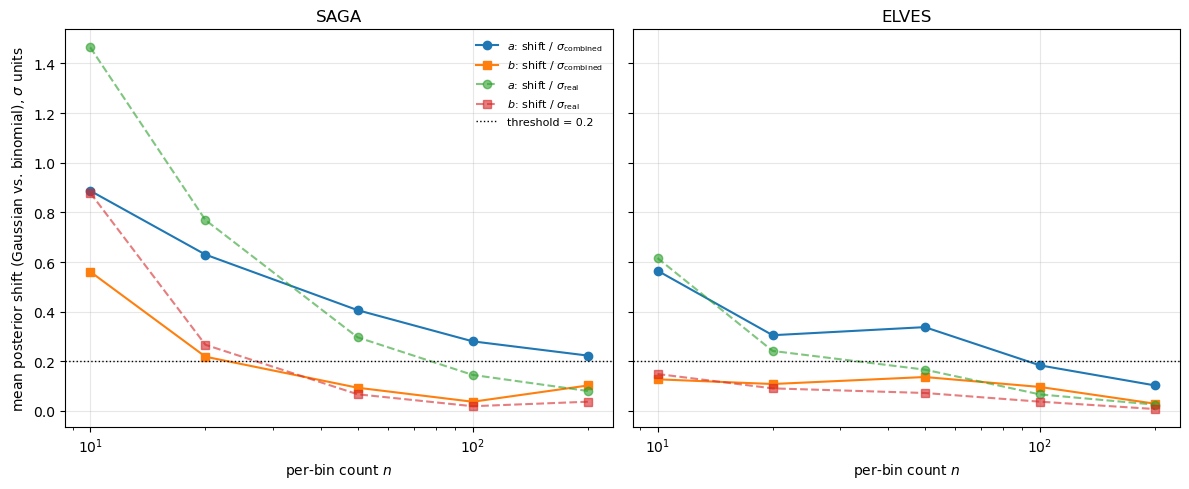

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, label, df, sig_a, sig_b in [
    (axes[0], "SAGA", sweep_saga, sigma_a_saga, sigma_b_saga),
    (axes[1], "ELVES", sweep_elves, sigma_a_elves, sigma_b_elves),
]:
    ax.plot(df["n_per_bin"], df["shift_a_sigma_mean"], "o-", label=r"$a$: shift / $\sigma_{\rm combined}$")
    ax.plot(df["n_per_bin"], df["shift_b_sigma_mean"], "s-", label=r"$b$: shift / $\sigma_{\rm combined}$")
    ax.plot(df["n_per_bin"], df["shift_a_realposterior_mean"], "o--", alpha=0.6,
            label=r"$a$: shift / $\sigma_{\rm real}$")
    ax.plot(df["n_per_bin"], df["shift_b_realposterior_mean"], "s--", alpha=0.6,
            label=r"$b$: shift / $\sigma_{\rm real}$")
    ax.axhline(SHIFT_THRESHOLD, color="k", ls=":", lw=1, label=f"threshold = {SHIFT_THRESHOLD}")
    ax.set_xscale("log")
    ax.set_xlabel("per-bin count $n$")
    ax.set_title(label)
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r"mean posterior shift (Gaussian vs. binomial), $\sigma$ units")
axes[0].legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

---
## Section F. Comparison to the smallest actual bin and the generic rule

In [ ]:
def rule_of_thumb_needed_n(a_true, b_true, bin_centers_deg):
    """Smallest per-bin n at which BOTH n*p >= 5 AND n*(1-p) >= 5 hold for EVERY bin
    at the given (a_true, b_true) evaluated on bin_centers_deg."""
    p = a_true + b_true * np.cos(2 * np.radians(np.asarray(bin_centers_deg)))
    worst = np.maximum(1.0 / np.clip(p, 1e-9, None), 1.0 / np.clip(1 - p, 1e-9, None))
    # n * min(p, 1-p) >= 5  <=>  n >= 5 / min(p, 1-p)
    needed = 5.0 * np.max(np.maximum(1.0 / np.clip(p, 1e-9, None),
                                     1.0 / np.clip(1 - p, 1e-9, None)))
    return int(np.ceil(needed))

n_thumb_saga = rule_of_thumb_needed_n(a_saga_true, b_saga_true, bin_centers)
n_thumb_elves = rule_of_thumb_needed_n(a_elves_true, b_elves_true, bin_centers)
print(f"Rule-of-thumb (n*p >= 5 AND n*(1-p) >= 5) minimum n per bin at fitted (a,b):")
print(f"  SAGA:  {n_thumb_saga}")
print(f"  ELVES: {n_thumb_elves}")

print("\nSmallest actual bin count in data:")
print(f"  SAGA:  {int(n_saga.min())}")
print(f"  ELVES: {int(n_elves.min())}")

Rule-of-thumb (n*p >= 5 AND n*(1-p) >= 5) minimum n per bin at fitted (a,b):
  SAGA:  24
  ELVES: 16

Smallest actual bin count in data:
  SAGA:  8
  ELVES: 6


---
## Section G. Summary (auto-populated)

In [ ]:
def summarize(label, df, sig_a_real, sig_b_real, n_thumb, n_smallest_actual):
    n_thresh = smallest_n_below(df, "shift_b_sigma_mean", SHIFT_THRESHOLD)
    n_thresh_realb = smallest_n_below(df, "shift_b_realposterior_mean", SHIFT_THRESHOLD)
    print(f"[{label}]")
    print(f"  Rule-of-thumb minimum n (n*p >= 5, generic):     {n_thumb}")
    print(f"  Data-derived n so |b_G - b_binom| < 0.2 sigma:   {n_thresh}   "
          f"(combined-sigma normalization)")
    print(f"                                                   {n_thresh_realb}   "
          f"(real-fit sigma normalization)")
    print(f"  Smallest actual bin in data:                     {n_smallest_actual}")
    if n_thresh is None:
        print("  --> even the largest n tested did not converge below the threshold; "
              "consider extending the grid or loosening the threshold.")
    else:
        if n_smallest_actual >= n_thresh:
            verdict = "SAFE"
        else:
            verdict = "MARGINAL / UNSAFE"
        print(f"  Verdict: smallest actual bin ({n_smallest_actual}) vs. required ({n_thresh}) --> {verdict}")

summarize("SAGA", sweep_saga, sigma_a_saga, sigma_b_saga, n_thumb_saga, int(n_saga.min()))
print()
summarize("ELVES", sweep_elves, sigma_a_elves, sigma_b_elves, n_thumb_elves, int(n_elves.min()))

[SAGA]
  Rule-of-thumb minimum n (n*p >= 5, generic):     24
  Data-derived n so |b_G - b_binom| < 0.2 sigma:   50   (combined-sigma normalization)
                                                   50   (real-fit sigma normalization)
  Smallest actual bin in data:                     8
  Verdict: smallest actual bin (8) vs. required (50) --> MARGINAL / UNSAFE

[ELVES]
  Rule-of-thumb minimum n (n*p >= 5, generic):     16
  Data-derived n so |b_G - b_binom| < 0.2 sigma:   10   (combined-sigma normalization)
                                                   10   (real-fit sigma normalization)
  Smallest actual bin in data:                     6
  Verdict: smallest actual bin (6) vs. required (10) --> MARGINAL / UNSAFE


### How to read this

- **`Rule-of-thumb minimum n`** is what the textbook $n p \geq 5$,
  $n(1-p) \geq 5$ criterion demands for **this** dataset's fitted $(a,b)$.
  It's the number you'd defend against a referee purely from statistics
  folklore, with no reference to your model or MCMC.
- **`Data-derived n so |b_G − b_binom| < 0.2σ`** is the answer this
  simulation actually provides: the smallest $n$ at which the Gaussian
  and binomial *posteriors* on $b$ (your anisotropy amplitude of
  interest) agree to within 0.2σ. This is the concrete replacement for
  the generic rule.
- **`Smallest actual bin`** is the $n$ your data actually delivers in
  its worst bin. Compare it to the derived threshold to know whether
  the Gaussian likelihood is genuinely safe for *your* analysis.

In `REDUCED_MODE = True` the sweep uses fewer MCMC steps and fewer
repeats, so the numbers here are noisier. Flip `REDUCED_MODE = False`
and re-run for a tight answer.